In [71]:
import pandas as pd
import numpy as np

In [597]:
#підключення до файлу з даними
ab_data = pd.read_csv('Downloads/ab_test_data.csv')

In [599]:
#перегляд інформації про дані в таблиці
ab_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19998 entries, 0 to 19997
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     19998 non-null  object
 1   timestamp   19998 non-null  object
 2   test_group  19998 non-null  object
 3   conversion  19998 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 625.1+ KB


In [601]:
#переглядаю статистику по стовпцям
ab_data.describe()

,conversion
count,19998.000000
mean,0.075008
std,0.263410
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [603]:
#дивлюсь, який вигляд мають дані в таблиці
ab_data.sample(10)

,user_id,timestamp,test_group,conversion
8982,e4375a0e-d454-4ef3-a9e2-d4e345d8011a,2023-07-13 20:11:44.264700,b,0
5289,9580c2d5-c328-4482-a9fd-8d2dc114e1dc,2023-07-13 16:15:11.418325,a,0
9082,4e0461b7-3768-412e-b5cd-e153fc90eebf,2023-07-17 18:57:12.707076,b,0
15563,42a1de23-ebfe-49d8-afa0-c5c9db859ce5,2023-07-24 18:04:40.290938,b,0
3566,3de5b434-b422-4af2-bb40-3590396586ae,2023-07-17 12:52:02.450767,a,0
7967,ce619dec-a4ea-4423-80c6-fe197d24c4ba,2023-07-03 14:32:23.408569,b,0
18664,9b2c999d-48c7-4373-8452-2dec37357fb5,2023-07-23 15:48:54.236255,b,0
4552,d4f0dcd8-af5c-475c-9fd5-1a162254f0b6,2023-07-16 21:22:17.222484,b,0
8047,1e3ea586-1ded-44d4-81c2-e3c8adf48c08,2023-07-24 09:42:04.534968,a,0
4264,979cc110-08c4-4ee9-b07b-1278325ce8b0,2023-07-18 05:13:34.210597,a,0


In [605]:
ab_data.groupby('test_group').describe()

conversion                                             
                count      mean       std  min  25%  50%  75%  max
test_group                                                        
a             10013.0  0.061021  0.239380  0.0  0.0  0.0  0.0  1.0
b              9985.0  0.089034  0.284806  0.0  0.0  0.0  0.0  1.0

In [607]:
#переводжу дати у формат datetime64[ns]
ab_data['timestamp'] = pd.to_datetime(ab_data['timestamp'])

In [609]:
#перевіряю як змінились дані
ab_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19998 entries, 0 to 19997
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     19998 non-null  object        
 1   timestamp   19998 non-null  datetime64[ns]
 2   test_group  19998 non-null  object        
 3   conversion  19998 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 625.1+ KB


In [665]:
# рахую кількість користувачів у групі "a"
count_group_A = ab_data.loc[ab_data['test_group'] == 'a'].shape[0]
count_group_A

10013

In [613]:
# group_B = ab_data.groupby(ab_data['test_group'].str.contains('b', case= False)).count()
# рахую кількість користувачів у групі "b"
count_group_B = ab_data.loc[ab_data['test_group'] == 'b'].shape[0]
count_group_B

9985

In [663]:
#рахую кількість користувачів, що пройшли конверсію в групі "a"
count_conversion_a = ab_data.loc[ab_data['test_group'] == 'a', 'conversion'].sum()
count_conversion_a
# group_conversion_a = ab_data.groupby(ab_data['test_group'].str.contains('a'))['conversion'].sum()
# group_conversion_a

611

In [647]:
average_a =count_conversion_a = ab_data.loc[ab_data['test_group'] == 'a', 'conversion'].mean()
average_a

0.06102067312493758

In [649]:
#рахую кількість користувачів, що пройшли конверсію в групі "b"
count_conversion_b = ab_data.loc[ab_data['test_group'] == 'b', 'conversion'].sum()
count_conversion_b
# group_conversion_a = ab_data.groupby(ab_data['test_group'].str.contains('a'))['conversion'].sum()
# group_conversion_a

889

In [651]:
average_b = ab_data.loc[ab_data['test_group'] == 'b', 'conversion'].mean()
average_b

0.08903355032548824

In [669]:
#рахую конверсію для групи "a"
conversion_a = round((count_conversion_a / count_group_A)*100,2)
conversion_a

6.1

In [631]:
#рахую конверсію для групи "b"
conversion_b = round((count_conversion_b / count_group_B)*100,2)
conversion_b

8.9

In [627]:
# вираховую дату початку та дату кінця тесту
start_test = (ab_data['timestamp'].min()).date()
print(f'Test starts {start_test}')
end_test = (ab_data['timestamp'].max()).date()
print(f'Test was ending {end_test}')

Test starts 2023-07-03
Test was ending 2023-07-25


In [296]:
#df['C'] = (df['B'] - df['A']).dt.days
test_duration = (end_test - start_test).days
test_duration

22

In [298]:
from scipy import stats

In [455]:
#вказую рівнень значущості
alpha = 0.05
#застосовую Student's t-test для тестування гіпотез та обраховую значення статистики та p-value
ststistic, pvalue = stats.ttest_ind(ab_data[ab_data['test_group'] == 'a']['conversion'],
                                    ab_data[ab_data['test_group'] == 'b']['conversion'],
                                    alternative='less')
print(f't-statistic: {round(ststistic,2)}, p-value: {round(pvalue,2)}')
if pvalue<alpha:
    print('Нулеву гіпотезу відхилено; різниця є статистично значимою')
else:
    print('Нулеву гіпотезу прийнято; різниця не є статистично значимою')

t-statistic: -7.53, p-value: 0.0
Нулеву гіпотезу відхилено; різниця є статистично значимою


In [325]:
import matplotlib.pyplot as plt
import seaborn as sns

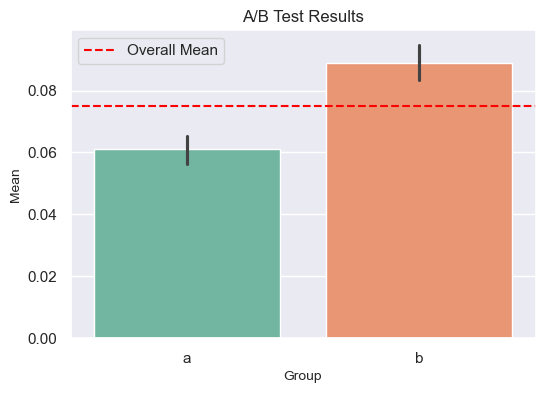

In [565]:
plt.figure(figsize=(6,4))
sns.barplot(x=ab_data['test_group'],
            y=ab_data['conversion'],hue=ab_data['test_group'],palette='Set2',
            errorbar=('ci', 95)) #95% довірчі інтервали
plt.title('A/B Test Results')
plt.xlabel('Group',fontsize=10)
plt.ylabel('Mean',fontsize=10)
overall_mean = ab_data['conversion'].mean()
plt.axhline(y=overall_mean, color='red', linestyle='--', label='Overall Mean')
plt.legend()
plt.savefig('sample.jpeg')

In [539]:
#стоворюю колонку де з datetime витягую лише дату
ab_data['date'] = pd.to_datetime(ab_data['timestamp']).dt.date
ab_data['date']

0        2023-07-04
1        2023-07-06
2        2023-07-10
3        2023-07-20
4        2023-07-19
            ...    
19993    2023-07-06
19994    2023-07-03
19995    2023-07-23
19996    2023-07-03
19997    2023-07-19
Name: date, Length: 19998, dtype: object

In [543]:
#групую за датою та тестовою групую
grouped_data = ab_data.groupby(['test_group', 'date']).agg({'conversion': 'mean'}).reset_index()

In [545]:
#розділяю на групу A та B
cumulative_metric_a = grouped_data[grouped_data['test_group'] == 'a']['conversion'].expanding().mean().reset_index(drop=True)
cumulative_metric_b = grouped_data[grouped_data['test_group'] == 'b']['conversion'].expanding().mean().reset_index(drop=True)

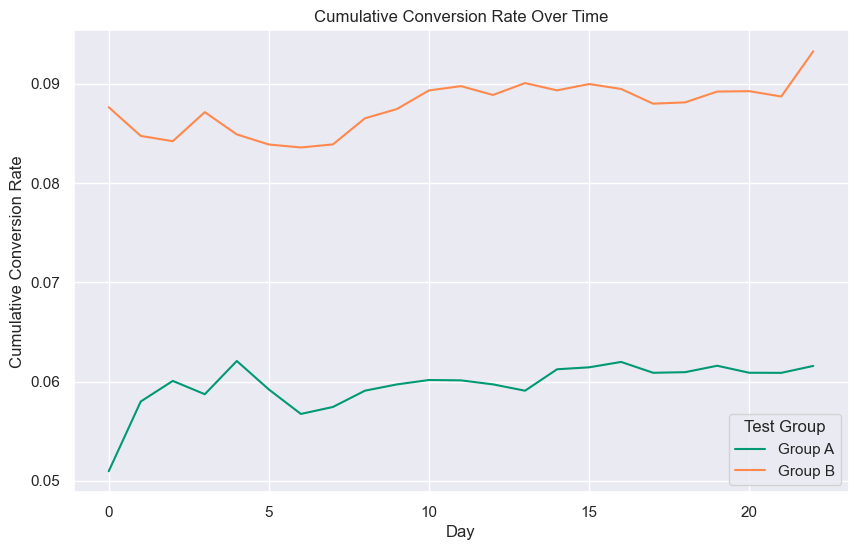

In [571]:
#будую графік, що відображає зміну конверсії в часі
plt.figure(figsize=(10, 6))
plt.plot(cumulative_metric_a, label='Group A', color='#009973')
plt.plot(cumulative_metric_b, label='Group B', color='#ff884d')
plt.title('Cumulative Conversion Rate Over Time')
plt.xlabel('Day')
plt.ylabel('Cumulative Conversion Rate')
plt.legend(title='Test Group')
plt.grid(True)
#plt.show()
plt.savefig('Cumulative Conversion Rate.jpeg')